# Use case 1: vertebrate gallbladder bile (MSV000085120)

**Produces:** Figure 2A (`boxplots_class`, class level) and the matching order-level figure (`boxplots_order`).

**Inputs:** GNPS2 FBMN task `ea3628cec9d042358b558f86edc781c1` (quantification table downloaded and cached in `data/`), the post-molecular-networking MassQL table `library_matches_PostMN_MassQL.tsv` and the sample metadata `metadata.txt` (set `BASE_DIR` in the config cell).

In [11]:
import os

# Root of the local project folder (the one holding Falcon/, Queries_final_mgf/,
# final_mgfs_library_generation/, ...). Edit this single line to run elsewhere.
PROJECT_DIR = '/media/dorrestein/Helena2/Bile_acids_update'

# Bile-salt core composition across vertebrates — publication figures

Runs top to bottom from a clean kernel and produces exactly two figures:

* **Figure A.1** — class level, ten lineages.
* **Figure A.2** — order level, every NCBI order with at least `MIN_N` files.

Both use the same layout and the same single score: each core's share of the
annotated bile-acid pool. The two ranks are kept in separate figures and never
mixed within one — a class row and an order row are not comparable observations.

**What these figures do not show.** The libraries cover C23, C24, C24-alkamine,
C26 aceto, C27 bile **acids** and C28 bile **alcohols**. There is no C27 bile
**alcohol** query and negative ionisation mode was excluded, so sulfated C27 bile
alcohols — the dominant bile salts of sharks, rays, lungfish and coelacanth —
cannot appear. Rows whose expected bile salts fall in that gap are starred and
are not comparable with unmarked rows. Nothing here is molar: peak area depends
on ionisation efficiency and the cores carry unequal numbers of library entries
(C24 = 511, C28_alcohol = 18), so rows are read **down a column**, never across.

In [12]:
# ============================== CONFIG =======================================
%matplotlib inline
import os, re
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- inputs ------------------------------------------------------------------
TASK_ID   = 'ea3628cec9d042358b558f86edc781c1'
DATA_DIR  = 'data'         # GNPS2 downloads are cached here
FIG_DIR   = 'figures/bile_samples'      # figures and source data are written here

# local files that cannot be fetched from GNPS2 - repoint if run elsewhere
BASE_DIR      = f'{PROJECT_DIR}/Examples/Bile_samples_QToF'
METADATA_PATH = os.path.join(BASE_DIR, 'metadata.txt')
MASSQL_PATH   = os.path.join(BASE_DIR, 'library_matches_PostMN_MassQL.tsv')
MASSQL_SKIPROWS = 26

# --- output ------------------------------------------------------------------
SAVE_FIGURES = True
DPI = 300
mpl.rcParams['pdf.fonttype'] = 42     # editable text in Illustrator
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['savefig.dpi'] = DPI

# --- style -------------------------------------------------------------------
core_colors = {'C23': '#2a78d6', 'C24': '#eb6834', 'C24_alkamine': '#1baf7a',
               'C26': '#eda100', 'C27': '#e87ba4', 'C28_alcohol': '#008300'}
INK, TICK, RULE, GRID = '#0b0b0b', '#52514e', '#c3c2b7', '#e4e3df'
BAND_FILL, BAND_EDGE = '#f4f3ee', '#dedcd3'     # hatched band for starred rows
C27_TINT = '#fdf4f7'                            # emphasis on the result column

# --- analysis constants ------------------------------------------------------
MIN_N = 10                # rows below this are daggered; orders below it are dropped from A.2
PSEUDOREP_RATIO = 1.5     # files/species at or above this marks a pseudo-replicated row
EXPECTED_N_FILES = 1616
EXPECTED_CORES = {'C23': 30, 'C24': 511, 'C24_alkamine': 200,
                  'C26': 0, 'C27': 166, 'C28_alcohol': 18}

# NCBIClass is 'missing value' for lineages NCBI does not rank at class level.
# Actinistia and Dipnoi are real NCBI classes; Testudines and Crocodylia are not
# ranked because Reptilia is paraphyletic, so they stand as unranked lineages.
CLASS_FILL = {'Coelacanthiformes': 'Actinistia', 'Ceratodontiformes': 'Dipnoi',
              'Testudines': 'Testudines', 'Crocodylia': 'Crocodylia'}
UNRANKED_LINEAGES = ['Testudines', 'Crocodylia', 'Lepidosauria']

# --- row orders (phylogenetic, not sample size) - edit here -------------------
CLASS_ROWS = ['Chondrichthyes', 'Actinopteri', 'Actinistia', 'Dipnoi', 'Amphibia',
              'Mammalia', 'Lepidosauria', 'Testudines', 'Crocodylia', 'Aves']
CLASS_STARS = {'Chondrichthyes', 'Actinistia', 'Dipnoi'}

# A.2 is the intersection of this list with the orders that pass MIN_N; anything
# listed but not surviving is reported in section 2
ORDER_ROWS = ['Carcharhiniformes', 'Cypriniformes', 'Anguilliformes', 'Perciformes',
              'Scombriformes', 'Anura', 'Gymnophiona', 'Diprotodontia', 'Pilosa',
              'Rodentia', 'Primates', 'Carnivora', 'Perissodactyla', 'Artiodactyla',
              'Sirenia', 'Squamata', 'Testudines', 'Crocodylia', 'Anseriformes',
              'Galliformes', 'Columbiformes', 'Phoenicopteriformes', 'Sphenisciformes',
              'Ciconiiformes', 'Suliformes', 'Pelecaniformes', 'Accipitriformes',
              'Falconiformes', 'Gruiformes', 'Charadriiformes', 'Bucerotiformes',
              'Coraciiformes', 'Piciformes', 'Psittaciformes', 'Passeriformes']
# starred orders: caecilians, plus every order of a starred class (derived in section 2)
ORDER_STARS_EXPLICIT = {'Gymnophiona'}
STARRED_CLASSES = {'Chondrichthyes', 'Actinistia', 'Dipnoi'}

# --- captions ----------------------------------------------------------------
CAPTION_COMMON = [
    '(i) C27 here means C27 bile ACIDS only: this build has no C27 bile alcohol query and '
    'negative ionisation mode was excluded.',
    '(ii) The C27 gradient separates clades using the indirect C27-bile-acid pathway '
    '(Crocodylia, Testudines, Anura) from those using\n     the direct C27-alcohol-to-C24 '
    'route (Actinopteri, Lepidosauria, Aves, Mammalia).',
    '(iii) Starred rows are coverage-limited: their dominant bile salts are invisible to the '
    'queries used here, so their composition is\n      the minor fraction of a mostly-unseen '
    'pool and is not comparable to unmarked rows.']
CAPTION_A1_EXTRA = [
    '(iv) NCBI assigns no class rank to Testudines, Crocodylia or Lepidosauria (Reptilia is '
    'paraphyletic); they are shown as unranked\n     lineages.']

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
for path, what in [(METADATA_PATH, 'metadata'), (MASSQL_PATH, 'MassQL validation table')]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{what} not found at {path}\n   -> this file cannot be fetched from GNPS2; '
            f'edit BASE_DIR in this cell.')
print(f'config ok | task {TASK_ID} | cache {os.path.abspath(DATA_DIR)} | '
      f'figures -> {os.path.abspath(FIG_DIR)} | MIN_N={MIN_N} | SAVE_FIGURES={SAVE_FIGURES}')

config ok | task ea3628cec9d042358b558f86edc781c1 | cache /media/dorrestein/Helena2/Bile_acids_update/Manuscript/Github_refined/Figures/Figure2A_vertebrate_bile_use_case/data | figures -> /media/dorrestein/Helena2/Bile_acids_update/Manuscript/Github_refined/Figures/Figure2A_vertebrate_bile_use_case/figures/bile_samples | MIN_N=10 | SAVE_FIGURES=True


## 1. Load and filter

Feature table and library matches are downloaded once from the GNPS2 task and
cached in `data/`, so reruns are offline and fast. The MassQL post-networking
validation and the metadata are local files.

Filters, in order: MassQL-validated library matches only, then animal biofluids
only. Every expected count is asserted rather than printed and hoped for — if an
upstream input changes, this notebook stops instead of publishing a different
figure under the same caption.

**What this section does not do:** any normalisation. It only decides which
features and which files exist downstream.

In [13]:
# ---- 1.1 feature table (cached download) ------------------------------------
def fetch(url, path, what):
    '''download once, then reuse the cached copy on every later run.'''
    if os.path.exists(path):
        print(f'{what:22s} cached  {path}')
        return path
    print(f'{what:22s} downloading from GNPS2 ...')
    try:
        r = requests.get(url, timeout=900)
        r.raise_for_status()
    except Exception as exc:
        raise RuntimeError(
            f'could not download {what} and no cached copy exists at {path}.\n'
            f'   -> run once with a network connection, or drop the file in place '
            f'manually.\n   original error: {exc}') from exc
    with open(path, 'wb') as fh:
        fh.write(r.content)
    print(f'{what:22s} saved    {path} ({os.path.getsize(path) / 1e6:.0f} MB)')
    return path


quant_path = fetch(f'https://gnps2.org/result?task={TASK_ID}'
                   f'&viewname=quantificationdownload&resultdisplay_type=task',
                   os.path.join(DATA_DIR, f'{TASK_ID}_quant.csv'), 'quantification table')
lib_path = fetch(f'https://gnps2.org/resultfile?task={TASK_ID}'
                 f'&file=nf_output/library/merged_results_with_gnps.tsv',
                 os.path.join(DATA_DIR, f'{TASK_ID}_lib_match.tsv'), 'library matches')

quant = pd.read_csv(quant_path, sep=',', low_memory=False)
area_cols = [c for c in quant.columns if c.endswith('Peak area')]
X_all = quant.set_index('row ID')[area_cols].astype('float32').T
X_all.index = pd.Index([re.sub(r'\.(mzML|mzXML) Peak area$', '', c) for c in area_cols],
                       name='filename')
del quant
print(f'\nfeature table: {X_all.shape[0]} files x {X_all.shape[1]} features')

quantification table   cached  data/ea3628cec9d042358b558f86edc781c1_quant.csv
library matches        cached  data/ea3628cec9d042358b558f86edc781c1_lib_match.tsv

feature table: 1637 files x 47939 features


In [14]:
# ---- 1.2 library matches, MassQL validation, BA core ------------------------
lib_match = pd.read_csv(lib_path, sep='\t', low_memory=False)
massql = pd.read_csv(MASSQL_PATH, sep='\t', skiprows=MASSQL_SKIPROWS)

lib_match_merged = pd.merge(lib_match, massql[['#Scan#', 'query_validation']],
                            on='#Scan#', how='left')
n_hits = len(lib_match_merged)
lib_match_merged = lib_match_merged[
    lib_match_merged['query_validation'] != 'Did not pass any selected query'].copy()

# a left merge writes NaN where a scan has no MassQL row, and NaN != '...' is True,
# so an unvalidated scan would pass the filter above. Fail loudly if that happens.
n_nan = int(lib_match_merged['query_validation'].isna().sum())
assert n_nan == 0, (f'{n_nan} retained scans have no MassQL validation row: the merge is '
                    f'leaking. Filter on an explicit pass condition, not "!= did not pass".')


def classify_ba_core(library_name):
    '''C24_alkamine is tested before C24 - the alkamine names also start with C24.'''
    library_name = '' if pd.isna(library_name) else str(library_name)
    if library_name.startswith('C23'):
        return 'C23'
    if library_name.startswith('C24_alkamine'):
        return 'C24_alkamine'
    if library_name.startswith('C24'):
        return 'C24'
    if library_name.startswith('C26'):
        return 'C26'
    if library_name.startswith('C27'):
        return 'C27'
    if library_name.startswith('C28'):          # C28_bile_alcohol_library_batch*.mgf
        return 'C28_alcohol'
    return pd.NA


lib_match_merged['BA_core'] = lib_match_merged['LibraryName'].map(classify_ba_core)
assert lib_match_merged['BA_core'].notna().all(), 'a validated feature has no BA core'

core_of_feature = lib_match_merged.set_index('#Scan#')['BA_core'].astype(str).sort_index()
ba_features = core_of_feature.index.to_numpy()
n_per_core = core_of_feature.value_counts()
present_cores = [c for c in EXPECTED_CORES if n_per_core.get(c, 0) > 0]

got = {c: int(n_per_core.get(c, 0)) for c in EXPECTED_CORES}
assert got == EXPECTED_CORES, f'feature counts changed upstream: expected {EXPECTED_CORES}, got {got}'
assert set(X_all.columns).issuperset(ba_features), 'validated scans missing from the quant table'
print(f'library hits {n_hits} -> validated {len(lib_match_merged)} '
      f'(failed the queries: {n_hits - len(lib_match_merged)})')
print(f'{got}  |  plotted: {present_cores}  (C26 has a library but no surviving feature)')

library hits 1704 -> validated 925 (failed the queries: 779)
{'C23': 30, 'C24': 511, 'C24_alkamine': 200, 'C26': 0, 'C27': 166, 'C28_alcohol': 18}  |  plotted: ['C23', 'C24', 'C24_alkamine', 'C27', 'C28_alcohol']  (C26 has a library but no surviving feature)


In [15]:
# ---- 1.3 metadata, animal biofluids -----------------------------------------
metadata = pd.read_csv(METADATA_PATH, sep='\t')
metadata['filename'] = metadata['filename'].str.replace(r'\.(mzML|mzXML)$', '', regex=True)
samples_all = pd.DataFrame(index=X_all.index).join(metadata.set_index('filename'))

n_no_meta = int(samples_all['SampleType'].isna().sum())
n_tissue = int((samples_all['SampleTypeSub1'] == 'tissue').sum())
n_blank = int((samples_all['SampleType'] == 'blank_analysis').sum())
keep = samples_all.index[(samples_all['SampleType'] == 'animal')
                         & (samples_all['SampleTypeSub1'] == 'biofluid')]
samples = samples_all.loc[keep]
species = samples['NCBISpecies']

print(f'{len(samples_all)} files -> {len(samples)} animal biofluids '
      f'({n_blank} blanks, {n_tissue} tissue, {n_no_meta} without metadata removed)')
assert len(samples) == EXPECTED_N_FILES, \
    f'expected {EXPECTED_N_FILES} animal biofluid files, got {len(samples)}'

1637 files -> 1616 animal biofluids (0 blanks, 19 tissue, 2 without metadata removed)


## 2. Taxonomy — two columns, kept apart

`taxon_class` and `taxon_order` are built separately and never mixed inside one
figure.

**Class.** NCBIClass, with `'missing value'` filled from NCBIOrder for the four
lineages NCBI does not rank there: Coelacanthiformes → Actinistia and
Ceratodontiformes → Dipnoi are real NCBI classes; Testudines and Crocodylia have
no class rank at all because Reptilia is paraphyletic, so they stand as unranked
lineages beside Lepidosauria. The merged-Reptilia alternative is **printed, not
plotted**, so the cost of splitting is on record.

**Order.** NCBIOrder, dropping files with no order, then keeping orders with at
least `MIN_N` files. The full order table is printed *before* the cutoff so the
threshold can be revisited.

**What this section does not do:** any phylogenetic correction. Files within an
order share ancestry and are not independent; a row with many more files than
species is additionally pseudo-replicated and is flagged in Figure A.2.

In [16]:
# ---- 2.1 taxon_class ---------------------------------------------------------
filled = samples['NCBIClass'].where(samples['NCBIClass'] != 'missing value',
                                    samples['NCBIOrder'].map(CLASS_FILL))
unresolved = filled.isna() | (filled == 'missing value')
print(f'{int(unresolved.sum())} files have no usable class after the fill and are dropped '
      f'from Figure A.1')
taxon_class = filled[~unresolved].rename('taxon_class')

class_table = (pd.DataFrame({'g': taxon_class, 'sp': species.loc[taxon_class.index]})
               .groupby('g').agg(files=('sp', 'size'),
                                 species=('sp', lambda s: s[s != 'missing value'].nunique())))
missing_rows = [g for g in CLASS_ROWS if g not in class_table.index]
assert not missing_rows, f'CLASS_ROWS entries absent from the data: {missing_rows}'
extra_rows = [g for g in class_table.index if g not in CLASS_ROWS]
if extra_rows:
    print(f'note: present in the data but not in CLASS_ROWS, so not plotted: {extra_rows}')

# the alternative that is deliberately NOT plotted: one paraphyletic Reptilia row
rep_idx = taxon_class.index[taxon_class.isin(UNRANKED_LINEAGES)]
print(f'\nalternative (not plotted): merging {UNRANKED_LINEAGES} into one "Reptilia" row '
      f'would give {len(rep_idx)} files, '
      f'{species.loc[rep_idx][lambda s: s != "missing value"].nunique()} species; the '
      f'composition it would average away is printed with Figure A.1')
class_table.reindex(CLASS_ROWS)

21 files have no usable class after the fill and are dropped from Figure A.1

alternative (not plotted): merging ['Testudines', 'Crocodylia', 'Lepidosauria'] into one "Reptilia" row would give 296 files, 248 species; the composition it would average away is printed with Figure A.1


,files,species
g,,
Chondrichthyes,35,35
Actinopteri,173,155
Actinistia,1,1
Dipnoi,6,3
Amphibia,61,53
Mammalia,506,343
Lepidosauria,252,209
Testudines,30,25
Crocodylia,14,14


In [17]:
# ---- 2.2 taxon_order ---------------------------------------------------------
no_order = samples['NCBIOrder'] == 'missing value'
print(f'{int(no_order.sum())} files have NCBIOrder == "missing value" '
      f'({species[no_order][lambda s: s != "missing value"].nunique()} species) '
      f'and are dropped from Figure A.2')
taxon_order = samples.loc[~no_order, 'NCBIOrder'].rename('taxon_order')

order_table_full = (pd.DataFrame({'g': taxon_order, 'sp': species.loc[taxon_order.index]})
                    .groupby('g').agg(files=('sp', 'size'),
                                      species=('sp', lambda s: s[s != 'missing value'].nunique()))
                    .sort_values('files', ascending=False))
order_table_full['files_per_species'] = (order_table_full['files']
                                         / order_table_full['species'].replace(0, np.nan)).round(2)

passing = order_table_full.index[order_table_full['files'] >= MIN_N]
order_rows = [g for g in ORDER_ROWS if g in passing]
dropped_listed = [g for g in ORDER_ROWS if g not in passing]
unlisted = [g for g in passing if g not in ORDER_ROWS]
assert not unlisted, f'orders pass MIN_N but are missing from ORDER_ROWS: {unlisted}'

n_files_plotted = int(order_table_full.loc[order_rows, 'files'].sum())
print(f'\n{len(order_table_full)} orders total -> {len(order_rows)} with n >= {MIN_N} files, '
      f'covering {n_files_plotted} files')
print(f'listed in ORDER_ROWS but below the cutoff, so not plotted: {dropped_listed}')
print(f'(counting the {int(no_order.sum())} no-order files as one extra group would read as '
      f'{len(order_rows) + 1} groups / {n_files_plotted + int(no_order.sum())} files)')

# stars: caecilians, plus every surviving order belonging to a starred class
order_class = samples.loc[taxon_order.index].groupby(taxon_order)['NCBIClass'].agg(
    lambda s: s.mode().iat[0])
order_stars = set(ORDER_STARS_EXPLICIT) | {
    g for g in order_rows if order_class.get(g) in STARRED_CLASSES}
pseudo_rep = {g: '‡' for g in order_rows
              if order_table_full.loc[g, 'files_per_species'] >= PSEUDOREP_RATIO}
print(f'starred orders: {sorted(order_stars)}')
print(f'pseudo-replicated (files/species >= {PSEUDOREP_RATIO}): '
      f'{ {g: order_table_full.loc[g, "files_per_species"] for g in pseudo_rep} }')
order_table_full

52 files have NCBIOrder == "missing value" (26 species) and are dropped from Figure A.2

117 orders total -> 28 with n >= 10 files, covering 1292 files
listed in ORDER_ROWS but below the cutoff, so not plotted: ['Anguilliformes', 'Scombriformes', 'Pilosa', 'Sirenia', 'Sphenisciformes', 'Suliformes', 'Falconiformes']
(counting the 52 no-order files as one extra group would read as 29 groups / 1344 files)
starred orders: ['Carcharhiniformes', 'Gymnophiona']
pseudo-replicated (files/species >= 1.5): {'Rodentia': np.float64(1.79), 'Artiodactyla': np.float64(1.55), 'Phoenicopteriformes': np.float64(3.25)}


,files,species,files_per_species
g,,,
Squamata,252,209,1.21
Artiodactyla,200,129,1.55
Passeriformes,117,104,1.12
Carnivora,95,73,1.30
Anseriformes,69,62,1.11
...,...,...,...
Struthioniformes,1,1,1.00
Synbranchiformes,1,1,1.00
Torpediniformes,1,1,1.00


## 3. Compositional score

Each file is closed to 1 over all 925 annotated features, then summed within
core: `core_pct` is the share of that file's annotated bile-acid pool carried by
each core. Computed once; both figures read from it.

Closing per file removes the enormous concentration differences between bile
samples. **What it does not do:** make cores comparable to each other — see the
header note on ionisation and unequal library sizes.

In [18]:
# ---- 3. share of the annotated bile-acid pool -------------------------------
A_ba = X_all.loc[keep, ba_features]
total_ba_area = A_ba.sum(axis=1).astype('float64')
assert (total_ba_area > 0).all(), 'a file has no annotated bile-acid signal at all'

core_area = A_ba.T.groupby(core_of_feature).sum().T[present_cores].astype('float64')
core_pct = 100 * core_area.div(total_ba_area, axis=0)
assert np.allclose(core_pct.sum(axis=1), 100), 'compositions do not close to 100%'
print(f'core_pct: {core_pct.shape[0]} files x {core_pct.shape[1]} cores')
core_pct.head().round(2)

core_pct: 1616 files x 5 cores


BA_core,C23,C24,C24_alkamine,C27,C28_alcohol
filename,,,,,
BAX1000_2x_GC10_01_24737,0.59,84.57,7.88,6.68,0.28
BAX1001_2x_GC11_01_24738,0.69,80.18,2.25,16.86,0.02
BAX1002_2x_GD1_01_24742,0.35,70.02,5.08,24.54,0.01
BAX1003_2x_GD2_01_24743,0.24,89.31,1.99,8.41,0.05
BAX1004_2x_GD3_01_24744,7.97,56.22,4.86,30.22,0.73


## 4. Figures A.1 and A.2 (boxplots)

White box interiors, core-coloured outlines and points, no outliers, no legends. Figure A.1 (class level) is Figure 2A of the manuscript.

In [19]:
# ---- 6.1 white boxplots with coloured outlines and points ------------------
def draw_boxplot_panel(group_series, row_order, title,
                       exclude_potential_isf=False, min_files=3, row_h=0.52):
    """Alternative style for A.1/A.2; returns (figure, long source table)."""
    if 'Compound_Name' not in lib_match_merged.columns:
        raise KeyError('Compound_Name is required for the potential-ISF filter')

    selected_matches = lib_match_merged.copy()
    if exclude_potential_isf:
        is_potential_isf = selected_matches['Compound_Name'].astype('string').str.contains(
            'potential ISF', case=False, na=False)
        selected_matches = selected_matches.loc[~is_potential_isf].copy()

    selected_core_of_feature = (selected_matches.set_index('#Scan#')['BA_core']
                                .astype(str).sort_index())
    selected_features = selected_core_of_feature.index.to_numpy()
    plot_cores = [c for c in EXPECTED_CORES
                  if (selected_core_of_feature == c).any()]
    if not len(selected_features):
        raise ValueError('The selected feature filter leaves no bile-acid features')

    selected_area = X_all.loc[keep, selected_features]
    selected_total = selected_area.sum(axis=1).astype('float64')
    positive_files = selected_total.index[selected_total > 0]
    plot_core_area = (selected_area.loc[positive_files].T
                      .groupby(selected_core_of_feature).sum().T[plot_cores]
                      .astype('float64'))
    plot_core_pct = 100 * plot_core_area.div(selected_total.loc[positive_files], axis=0)

    group_series = group_series.loc[group_series.index.intersection(positive_files)]
    group_counts = group_series.value_counts()
    row_order = [g for g in row_order if group_counts.get(g, 0) >= min_files]
    if not row_order:
        raise ValueError(f'No groups have at least {min_files} files after filtering')
    idx_of = {g: group_series.index[group_series == g] for g in row_order}
    n_files = {g: len(idx_of[g]) for g in row_order}
    n_species = {g: int(species.loc[idx_of[g]][lambda s: s != 'missing value'].nunique())
                 for g in row_order}

    labels = []
    for g in row_order:
        labels.append(f'{g}  ({n_files[g]} file{"s" if n_files[g] != 1 else ""}, '
                      f'{n_species[g]} sp)')

    widths = [1.5 if c == 'C27' else 1.0 for c in plot_cores]
    fig, axes = plt.subplots(1, len(plot_cores), sharey=True,
                             figsize=(2.5 * sum(widths) + 3.4,
                                      row_h * len(row_order) + 2.4),
                             gridspec_kw=dict(width_ratios=widths))
    axes = np.atleast_1d(axes)
    records = []
    rng = np.random.default_rng(0)

    for ax, core in zip(axes, plot_cores):
        for i, g in enumerate(row_order):
            v = plot_core_pct.loc[idx_of[g], core].to_numpy()
            colour = core_colors[core]
            ax.boxplot(
                [v], positions=[i], vert=False, widths=0.56, notch=False,
                showfliers=False, patch_artist=True, manage_ticks=False,
                boxprops=dict(facecolor='white', edgecolor=colour, linewidth=1.5),
                whiskerprops=dict(color=colour, linewidth=1.5),
                capprops=dict(color=colour, linewidth=1.5),
                medianprops=dict(color=colour, linewidth=1.8),
                zorder=2)
            ax.scatter(v, i + rng.uniform(-0.15, 0.15, len(v)),
                       s=13, color=colour, alpha=0.48, linewidths=0, zorder=3)
            q1, med, q3 = np.percentile(v, [25, 50, 75])
            records.append({'group': g, 'core': core, 'n_files': n_files[g],
                            'n_species': n_species[g],
                            'exclude_potential_isf': exclude_potential_isf,
                            'median_pct': med, 'q25_pct': q1, 'q75_pct': q3})

        n_features = int((selected_core_of_feature == core).sum())
        ax.set_title(f'{core}\n{n_features} features',
                     fontsize=9.5, color=INK, fontweight='normal', pad=8)
        ax.set(xlabel='', ylabel='', xlim=(-4, 104))
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.grid(axis='x', color=GRID, linewidth=0.6)
        ax.set_axisbelow(True)
        for spine in ('top', 'right', 'left'):
            ax.spines[spine].set_visible(False)
        ax.spines['bottom'].set_color(RULE)
        ax.tick_params(labelsize=8, colors=TICK, length=0)

    axes[0].set_yticks(range(len(row_order)))
    axes[0].set_yticklabels(labels, fontsize=9, color=INK)
    axes[0].set_ylim(len(row_order) - 0.5, -0.5)
    fig.supxlabel('% of the annotated bile-acid pool', fontsize=10, color=TICK)
    fig.suptitle(title, fontsize=13, color=INK, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96))

    table = pd.DataFrame(records)
    table['group'] = pd.Categorical(table['group'], categories=row_order, ordered=True)
    table['core'] = pd.Categorical(table['core'], categories=plot_cores, ordered=True)
    return fig, table.sort_values(['group', 'core']).reset_index(drop=True)


print('draw_boxplot_panel ready')

draw_boxplot_panel ready


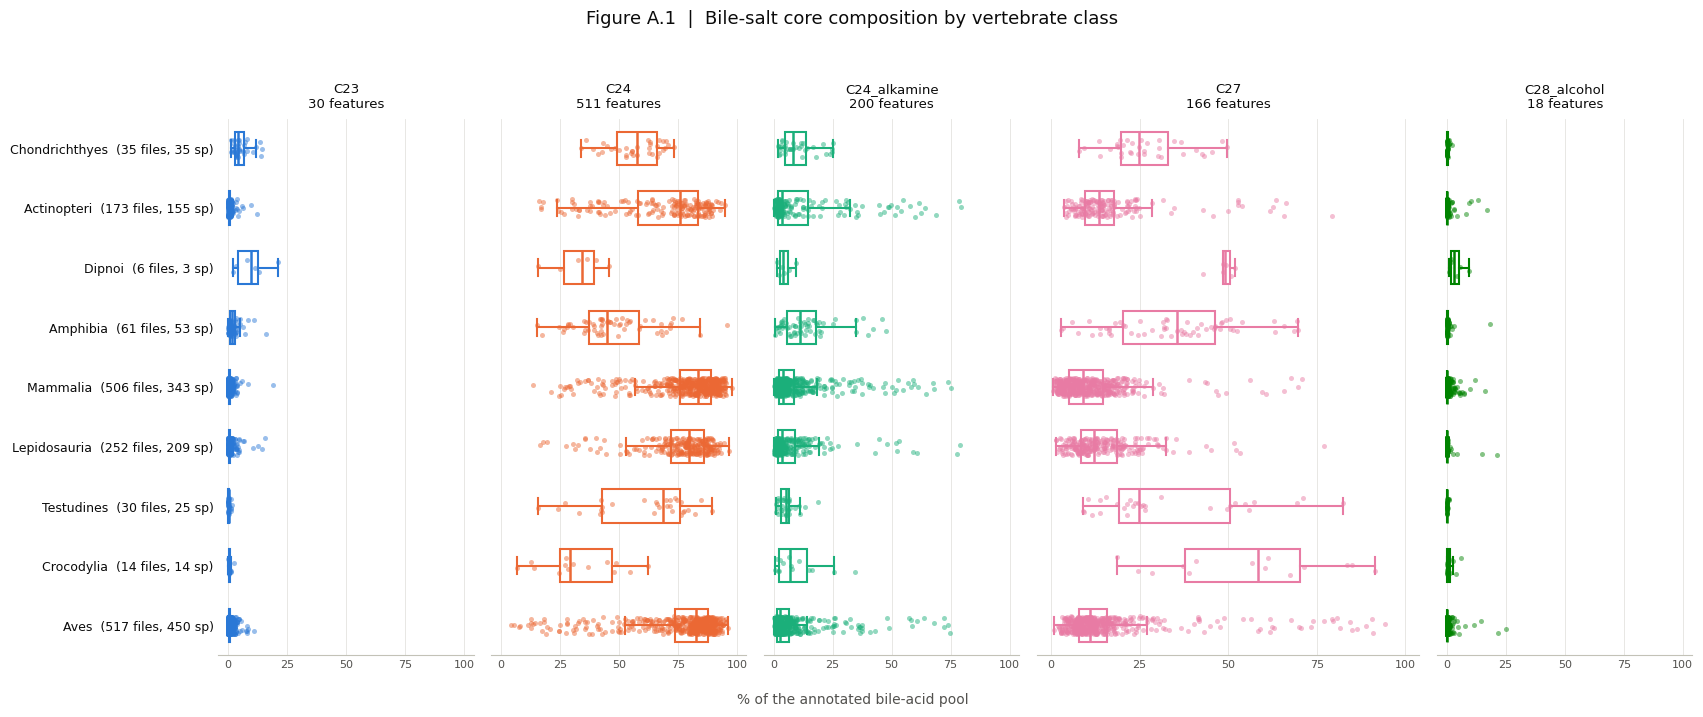

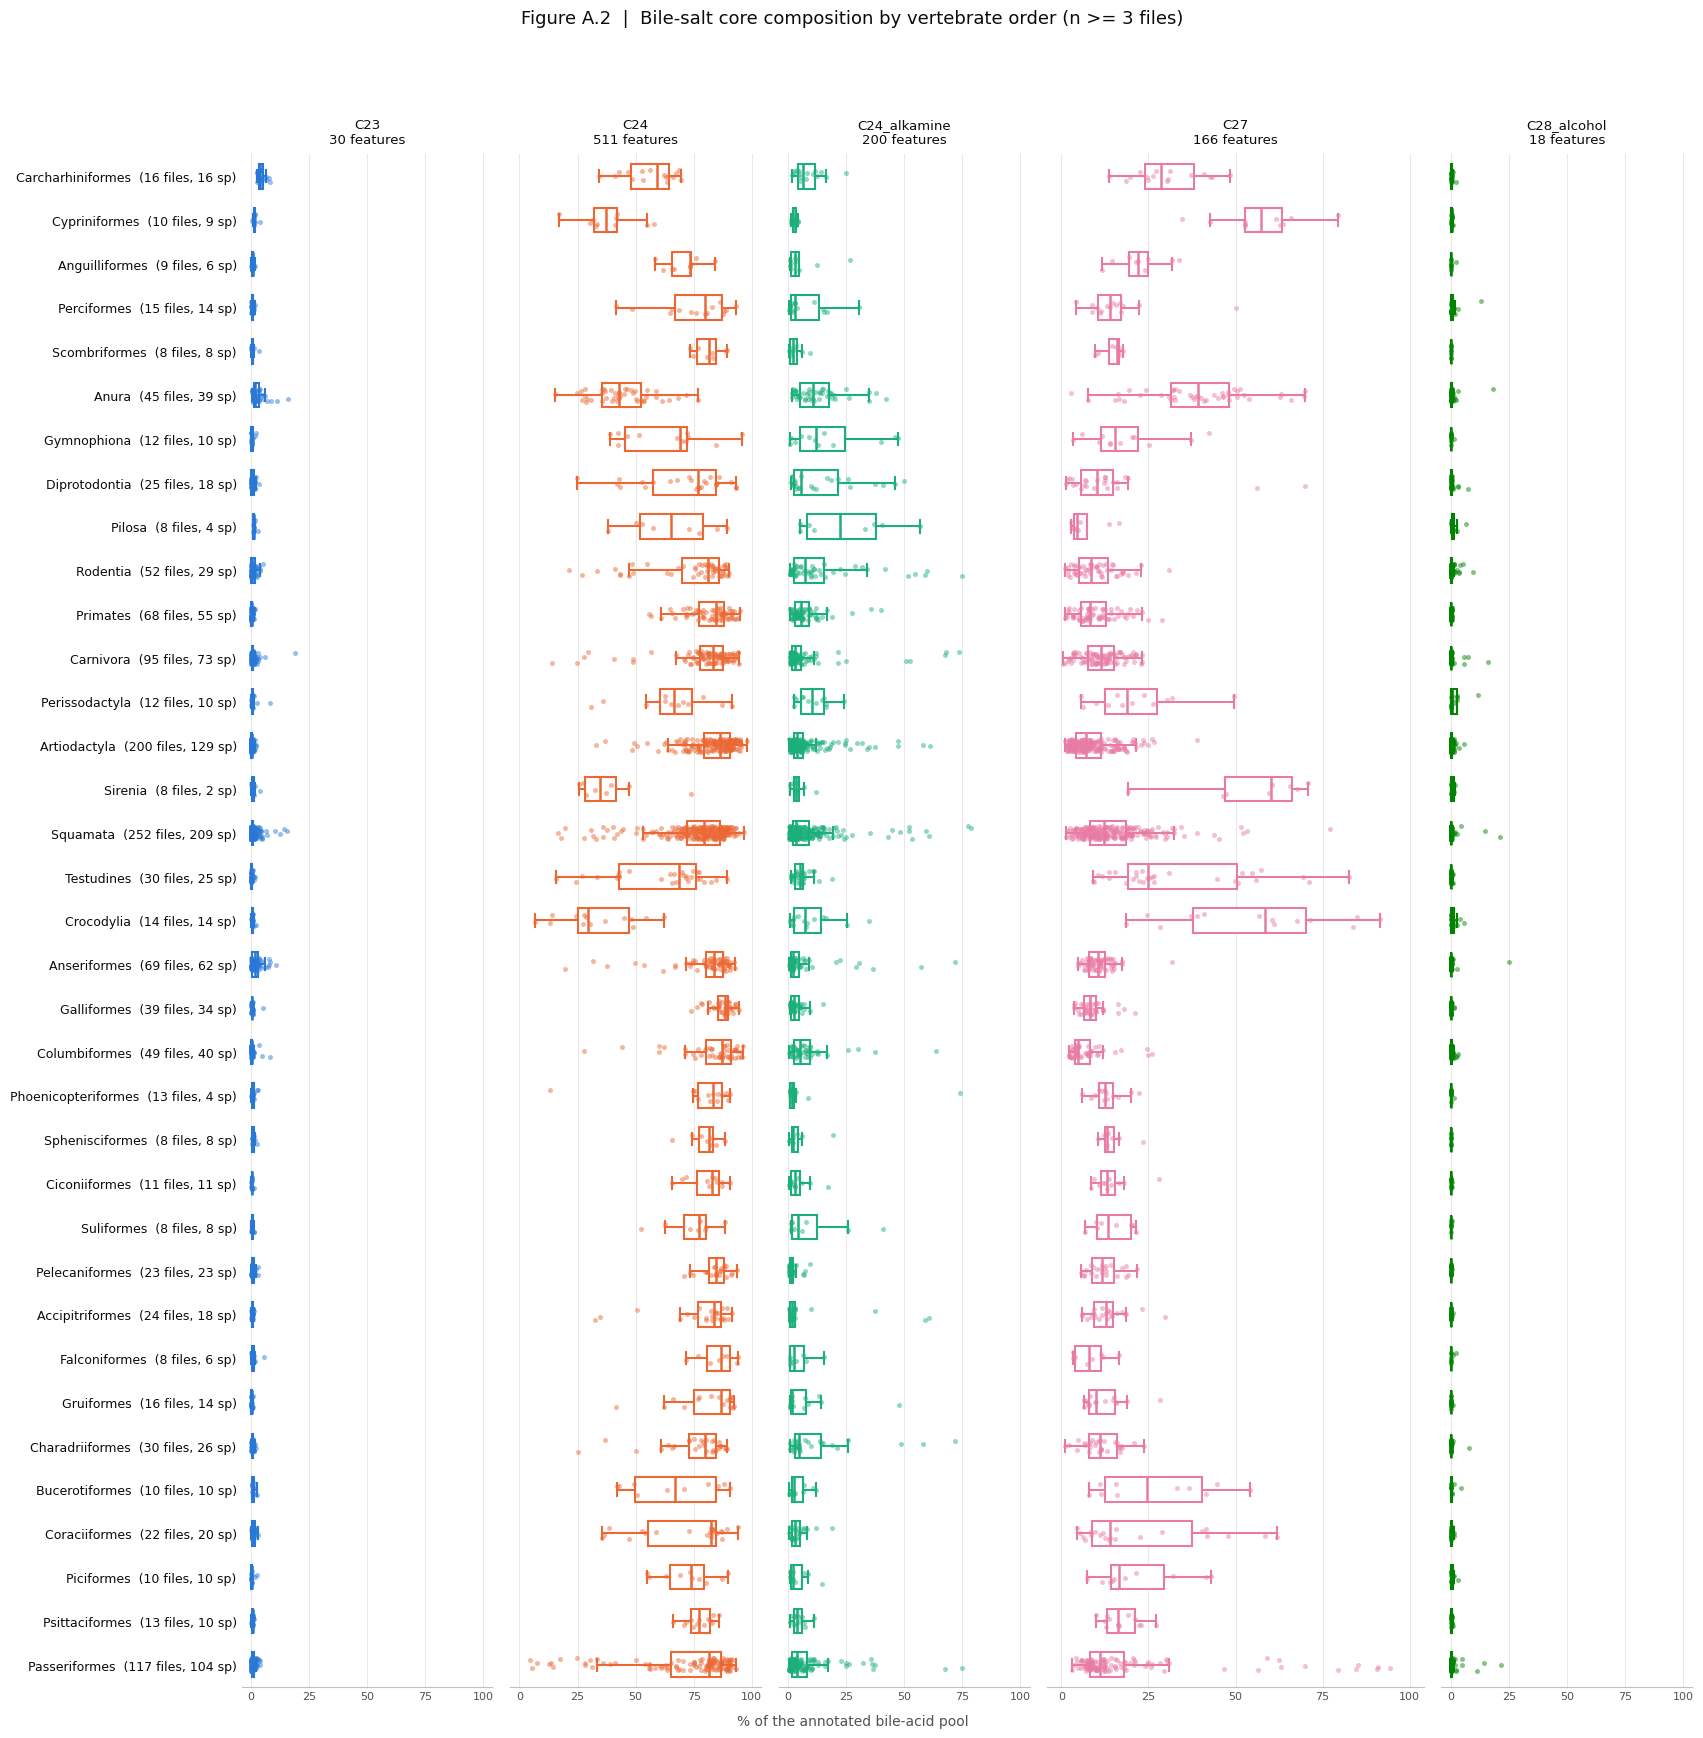

In [20]:
# ---- 6.2 alternative Figures A.1 and A.2 ----------------------------------
# Set to True to exclude features whose Compound_Name contains 'potential ISF'.
# Set to False to include them. This choice is applied to both figures below.
EXCLUDE_POTENTIAL_ISF = False
MIN_FILES_BOXPLOT = 3

fig_A1_box, table_A1_box = draw_boxplot_panel(
    taxon_class, CLASS_ROWS,
    'Figure A.1  |  Bile-salt core composition by vertebrate class',
    exclude_potential_isf=EXCLUDE_POTENTIAL_ISF,
    min_files=MIN_FILES_BOXPLOT, row_h=0.52)
plt.show()

fig_A2_box, table_A2_box = draw_boxplot_panel(
    taxon_order, ORDER_ROWS,
    f'Figure A.2  |  Bile-salt core composition by vertebrate order '
    f'(n >= {MIN_FILES_BOXPLOT} files)',
    exclude_potential_isf=EXCLUDE_POTENTIAL_ISF,
    min_files=MIN_FILES_BOXPLOT, row_h=0.43)
plt.show()

In [ ]:
# ---- 6.3 export alternative boxplot figures -------------------------------
if not SAVE_FIGURES:
    print('SAVE_FIGURES is False - boxplot figures not written')
else:
    written_boxplots = []
    for name, fig in [('boxplots_class', fig_A1_box),
                      ('boxplots_order', fig_A2_box)]:
        for ext in ('pdf', 'png'):
            path = os.path.join(FIG_DIR, f'{name}.{ext}')
            fig.savefig(path, dpi=DPI, bbox_inches='tight')
            written_boxplots.append(path)
    print('\n'.join(sorted(written_boxplots)))